In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [56]:
df=pd.read_csv("../DATASETS/headlines.csv" ,names=['text'])
df

,text
0,Budget to set scene for election\n \n Gordon B...
1,Army chiefs in regiments decision\n \n Militar...
2,Howard denies split over ID cards\n \n Michael...
3,Observers to monitor UK election\n \n Minister...
4,Kilroy names election seat target\n \n Ex-chat...
...,...
2220,India opens skies to competition\n \n India wi...
2221,Yukos bankruptcy 'not US matter'\n \n Russian ...
2222,Survey confirms property slowdown\n \n Governm...
2223,High fuel prices hit BA's profits\n \n British...


In [57]:
df.shape

(2225, 1)

In [58]:
print(df['text'][0])

Budget to set scene for election
 
 Gordon Brown will seek to put the economy at the centre of Labour's bid for a third term in power when he delivers his ninth Budget at 1230 GMT. He is expected to stress the importance of continued economic stability, with low unemployment and interest rates. The chancellor is expected to freeze petrol duty and raise the stamp duty threshold from Â£60,000. But the Conservatives and Lib Dems insist voters face higher taxes and more means-testing under Labour.
 
 Treasury officials have said there will not be a pre-election giveaway, but Mr Brown is thought to have about Â£2bn to spare.
 
 - Increase in the stamp duty threshold from Â£60,000 
  - A freeze on petrol duty 
  - An extension of tax credit scheme for poorer families 
  - Possible help for pensioners The stamp duty threshold rise is intended to help first time buyers - a likely theme of all three of the main parties' general election manifestos. Ten years ago, buyers had a much greater chanc

In [59]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer

swords = stopwords.words('english')

def clean_text(sent):
    tokens1 = word_tokenize(sent)
    tokens2 = [token for token in tokens1 if token.isalpha()]
    tokens3 = [token.lower() for token in tokens2 if token.lower() not in swords]
    return tokens3

sent = 'The raining was expected today. But not completed.'
clean_text(sent)

['raining', 'expected', 'today', 'completed']

In [60]:
wnl = WordNetLemmatizer()
wnl.lemmatize('expected', pos='v')

'expect'

In [61]:
def lemmatize(word):
    tags = pos_tag([word])
    if tags[0][1].startswith('V'):
        return wnl.lemmatize(word, pos='v')
    if tags[0][1].startswith('N'):
        return wnl.lemmatize(word, pos='n')
    if tags[0][1].startswith('J'):
        return wnl.lemmatize(word, pos='a')
    if tags[0][1].startswith('R'):
        return wnl.lemmatize(word, pos='r')

    return word



In [62]:
lemmatize('smallest')

'small'

In [63]:
lemmatize('went')

'go'

In [64]:
lemmatize('children')

'child'

In [65]:
def clean_text(sent):
    tokens1 = word_tokenize(sent)
    tokens2 = [token for token in tokens1 if token.isalpha()]
    tokens3 = [lemmatize(token.lower()) for token in tokens2 if token.lower() not in swords]
    return tokens3

In [66]:
clean_text(sent)

['rain', 'expect', 'today', 'complete']

In [67]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(analyzer=clean_text)

In [ ]:
x_new=tfidf.fit_transform(df['text'])
x_new

In [ ]:
from wordcloud import WordCloud

final_text = df['text'].apply(clean_text).sum()
final_text = " ".join(final_text)

wcloud = WordCloud().generate(final_text)


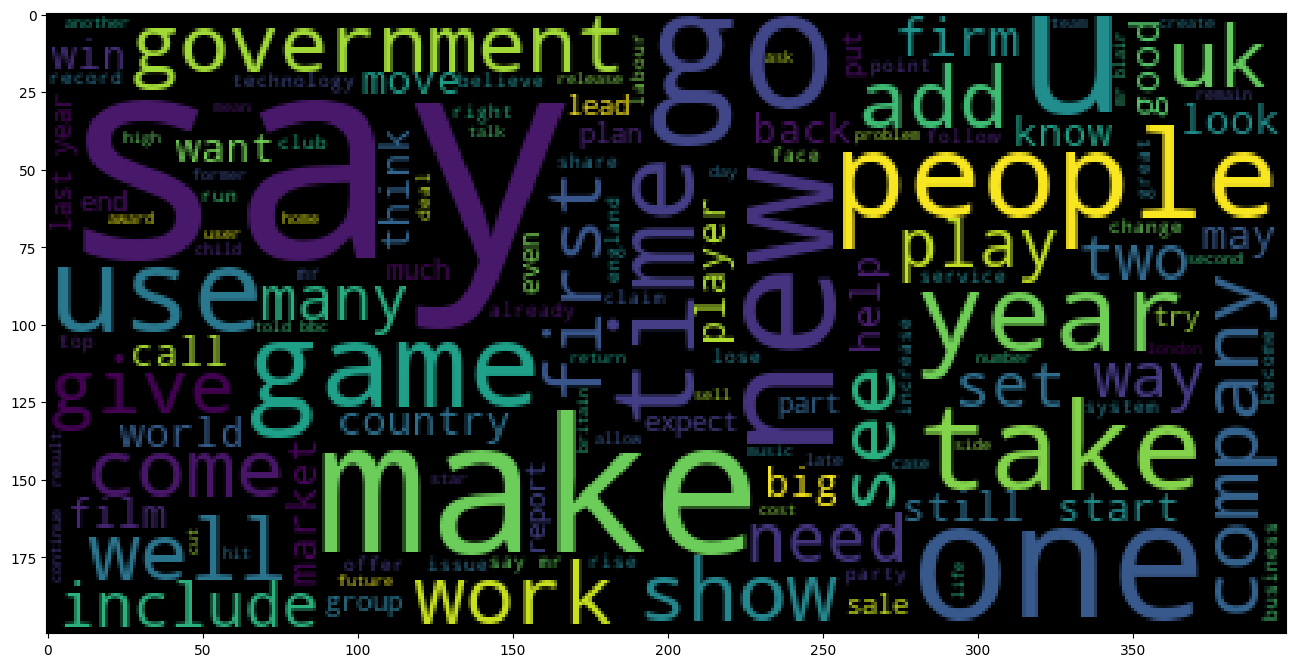

In [ ]:
plt.figure(figsize=(16,9))
plt.imshow(wcloud)

In [ ]:
swords.extend(['say','said','saying','make','made','one','u','new','go','gone','went'])

In [ ]:
def clean_text(sent):
    tokens1 = word_tokenize(sent)
    tokens2 = [token for token in tokens1 if token.isalpha()]
    tokens3 = [lemmatize(token.lower()) for token in tokens2 if token.lower() not in swords]
    return tokens3

In [ ]:
tfidf = TfidfVectorizer(analyzer=clean_text)


In [20]:
x_new = tfidf.fit_transform(df['text'])

In [21]:
x_new.shape

(2225, 21405)

#### identify the number of clusters 


In [22]:
from sklearn.cluster import KMeans

In [23]:
km=KMeans(n_clusters=5,n_init='auto')

In [24]:
km.fit(x_new)

InvalidParameterError: The 'init' parameter of KMeans must be a str among {'random', 'k-means++'}, a callable or an array-like. Got 'auto' instead.

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [25]:
km.inertia_

2101.7187479883855

In [27]:
sse = []
for k in range(1, 16):
    km = KMeans(n_clusters=k, n_init='auto')  # Fixed: changed init='auto' to n_init='auto' and set n_clusters=k
    km.fit(x_new)
    sse.append(km.inertia_)

In [45]:
from kneed import KneeLocator

# Initialize KneeLocator with the correct parameters
kl = KneeLocator(range(1, 16), sse, curve='convex', direction='decreasing')

# Print the calculated optimal number of clusters
print("Optimal number of clusters:", kl.elbow)

Optimal number of clusters: 9


In [46]:
# Create the clusters
km = KMeans(n_clusters=5, n_init='auto', random_state=0)
labels = km.fit_predict(x_new)
labels

array([4, 3, 4, ..., 3, 3, 3], shape=(2225,), dtype=int32)

In [47]:
zero=df['text'][labels==0]
zero

72      MPs issued with Blackberry threat\n \n MPs wil...
247     Game warnings 'must be clearer'\n \n Violent v...
300     MPs issued with Blackberry threat\n \n MPs wil...
373     UK firms 'embracing e-commerce'\n \n UK firms ...
928     Digital UK driven by net and TV\n \n The UK's ...
                              ...                        
1820    News Corp eyes video games market\n \n News Co...
1861    Brussels raps mobile call charges\n \n The Eur...
2054    Making your office work for you\n \n Our missi...
2138    Orange colour clash set for court\n \n A row o...
2149    BT offers equal access to rivals\n \n BT has m...
Name: text, Length: 376, dtype: str

In [48]:
zero = df['text'][labels==0]
one = df['text'][labels==1]
two = df['text'][labels==2]
three = df['text'][labels==3]
four = df['text'][labels==4]

zero.shape, one.shape, two.shape, three.shape, four.shape

((376,), (355,), (517,), (693,), (284,))

In [49]:
# Extract and clean the text data for cluster zero
zero=" ",(zero.apply(clean_text).sum())
zero


(' ',
 ['mp',
  'issue',
  'blackberry',
  'threat',
  'mp',
  'thrown',
  'common',
  'use',
  'blackberry',
  'chamber',
  'speaker',
  'michael',
  'martin',
  'rule',
  'handheld',
  'computer',
  'use',
  'phone',
  'pager',
  'send',
  'device',
  'gain',
  'prominence',
  'week',
  'alastair',
  'campbell',
  'use',
  'accidentally',
  'send',
  'message',
  'newsnight',
  'journalist',
  'mr',
  'martin',
  'reveal',
  'mp',
  'use',
  'blackberry',
  'debate',
  'also',
  'caution',
  'member',
  'use',
  'hidden',
  'earpiece',
  'use',
  'electronic',
  'device',
  'common',
  'chamber',
  'long',
  'frown',
  'sound',
  'mobile',
  'phone',
  'pager',
  'result',
  'strong',
  'rebuke',
  'either',
  'speaker',
  'deputy',
  'speaker',
  'chair',
  'debate',
  'common',
  'charge',
  'ensure',
  'order',
  'chamber',
  'enforce',
  'rule',
  'convention',
  'house',
  'always',
  'mp',
  'chosen',
  'colleague',
  'nominate',
  'give',
  'party',
  'political',
  'allegianc

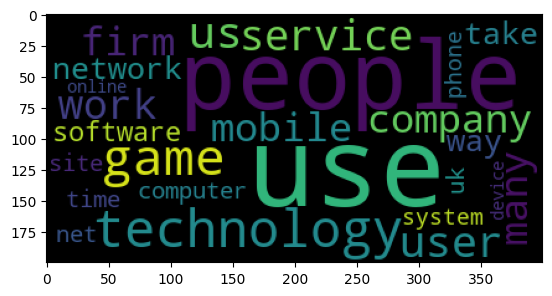

In [62]:
zero_wcloud = WordCloud(max_words=25).generate(zero)

plt.imshow(zero_wcloud)


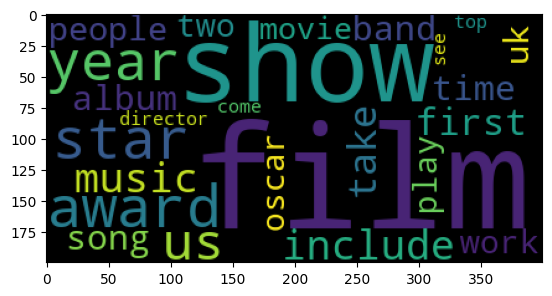

In [63]:
one_words = one.apply(clean_text).sum()
one_string = " ".join(one_words)
one_wcloud = WordCloud(max_words=25).generate(one_string)

plt.imshow(one_wcloud)

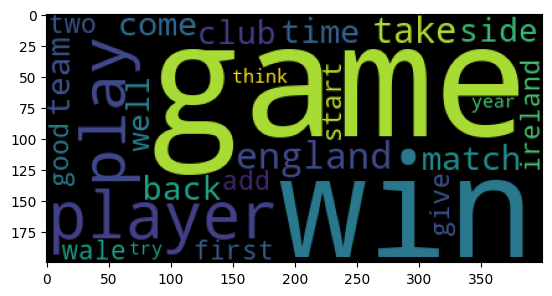

In [64]:
two_words = two.apply(clean_text).sum()
two_string = " ".join(two_words)
two_wcloud = WordCloud(max_words=25).generate(two_string)
plt.imshow(two_wcloud)

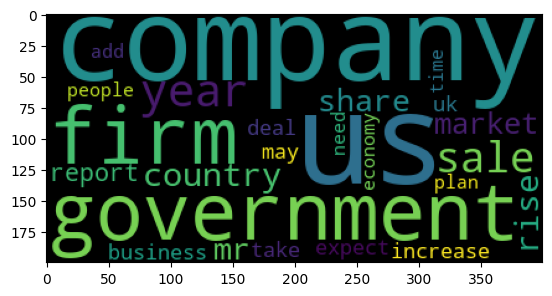

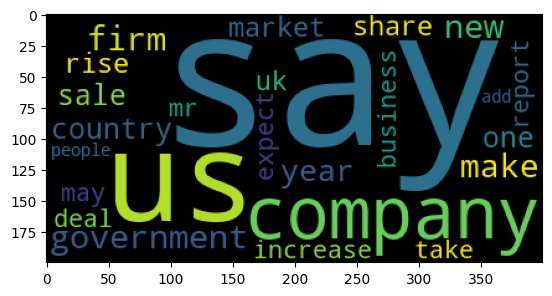

In [88]:
three_words = three.apply(clean_text).sum()
three_string = " ".join(three_words)
three_wcloud = WordCloud(max_words=25).generate(three_string)
plt.imshow(three_wcloud)

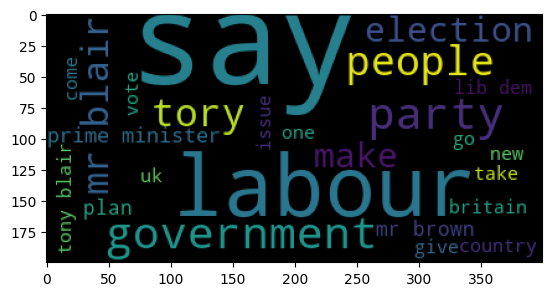

In [89]:
four_words = four.apply(clean_text).sum()
four_string = " ".join(four_words)
four_wcloud = WordCloud(max_words=25).generate(four_string)
plt.imshow(four_wcloud)